In [80]:
import matplotlib.pyplot as plt
import torch
from cryosim.icemaker import Icemaker
from cryosim.fft_tools import fft3
from tqdm import tqdm
from cryosim.plotting_tools import plot3d
import mrcfile
import torch.nn.functional as F
from cryosim.scattering import Scattering
from cryosim.microscope import Aberration, Detector
from cryosim.filters import butter

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
im = Icemaker(n=256, dx=1.0)

In [3]:
bigice = torch.squeeze(im.generate_big_ice((1, 1024, 4096, 4096)))

Output()

Output()

In [4]:
bigice = F.avg_pool3d(bigice[None, None], 2, 2)[0, 0]

In [5]:
bigice2 = torch.squeeze(im.generate_big_ice((1, 1024, 4096, 4096)))
bigice2 = F.avg_pool3d(bigice2[None, None], 2, 2)[0, 0]

Output()

Output()

In [6]:
ice = torch.cat((bigice, bigice2), dim=0)
ice.shape

torch.Size([1024, 2048, 2048])

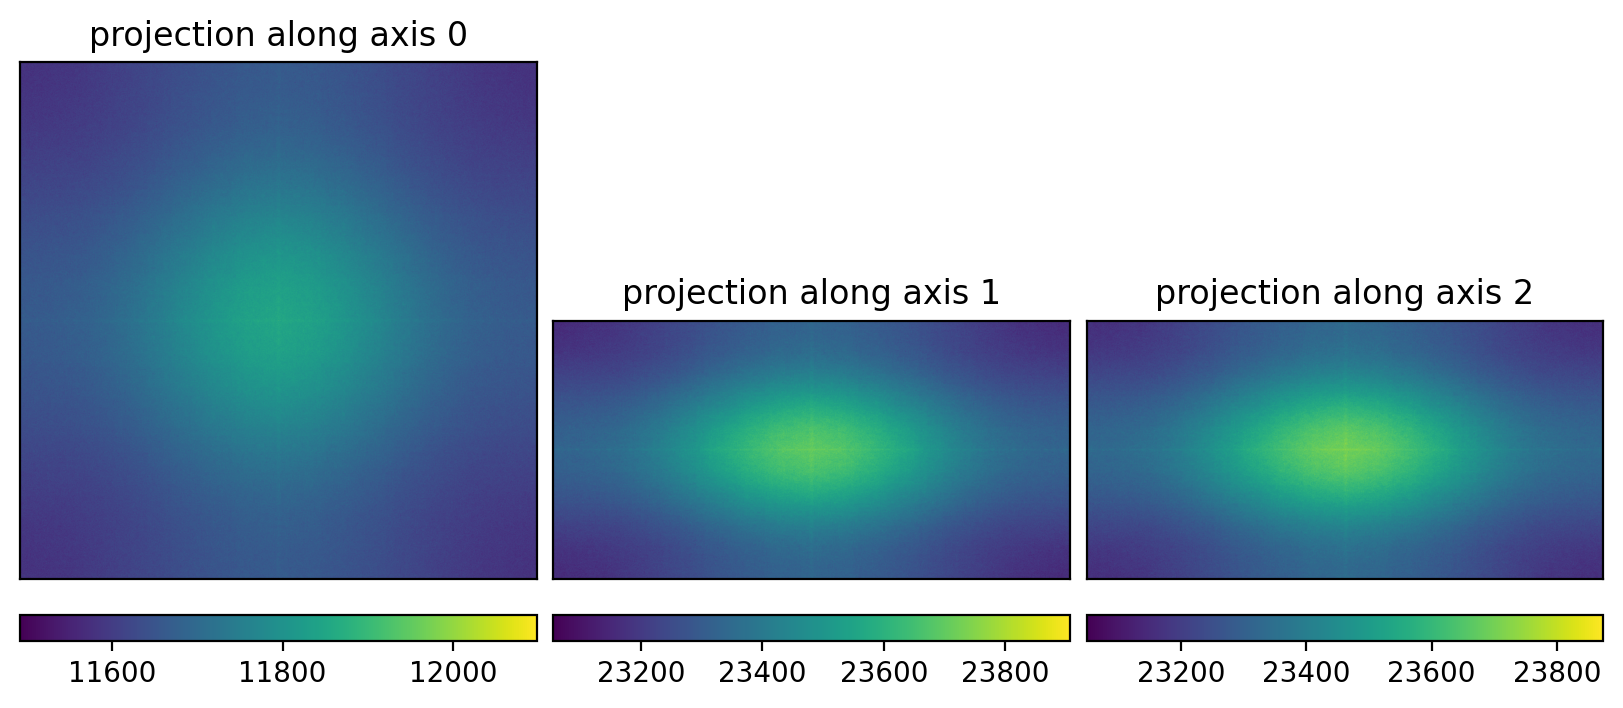

In [7]:
plot3d(torch.log(torch.abs(fft3(ice))))

In [8]:
with mrcfile.open(
    "/mnt/cbis/home/e0788253/polnet/gui/tomo_density_2048x2048x1024_2A.mrc"
) as mrc:
    tomo = torch.as_tensor(mrc.data[...].copy())

In [20]:
tomogram = tomo + ice * (tomo < 0.1)

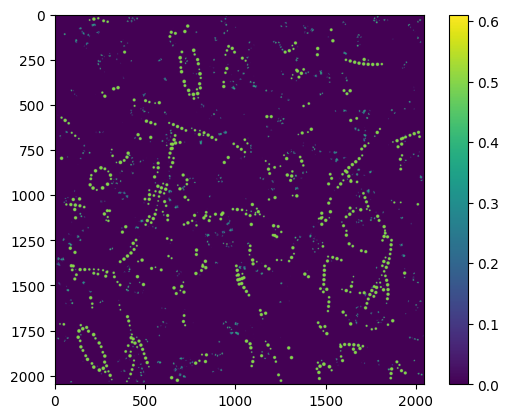

In [12]:
plt.imshow(tomo[200] * 0.5)
plt.colorbar()

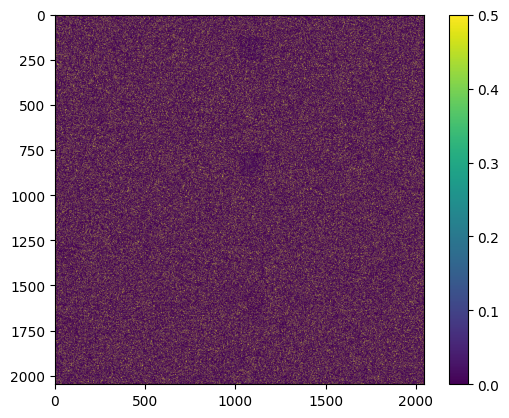

In [11]:
plt.imshow(ice[200], vmax=0.5)
plt.colorbar()

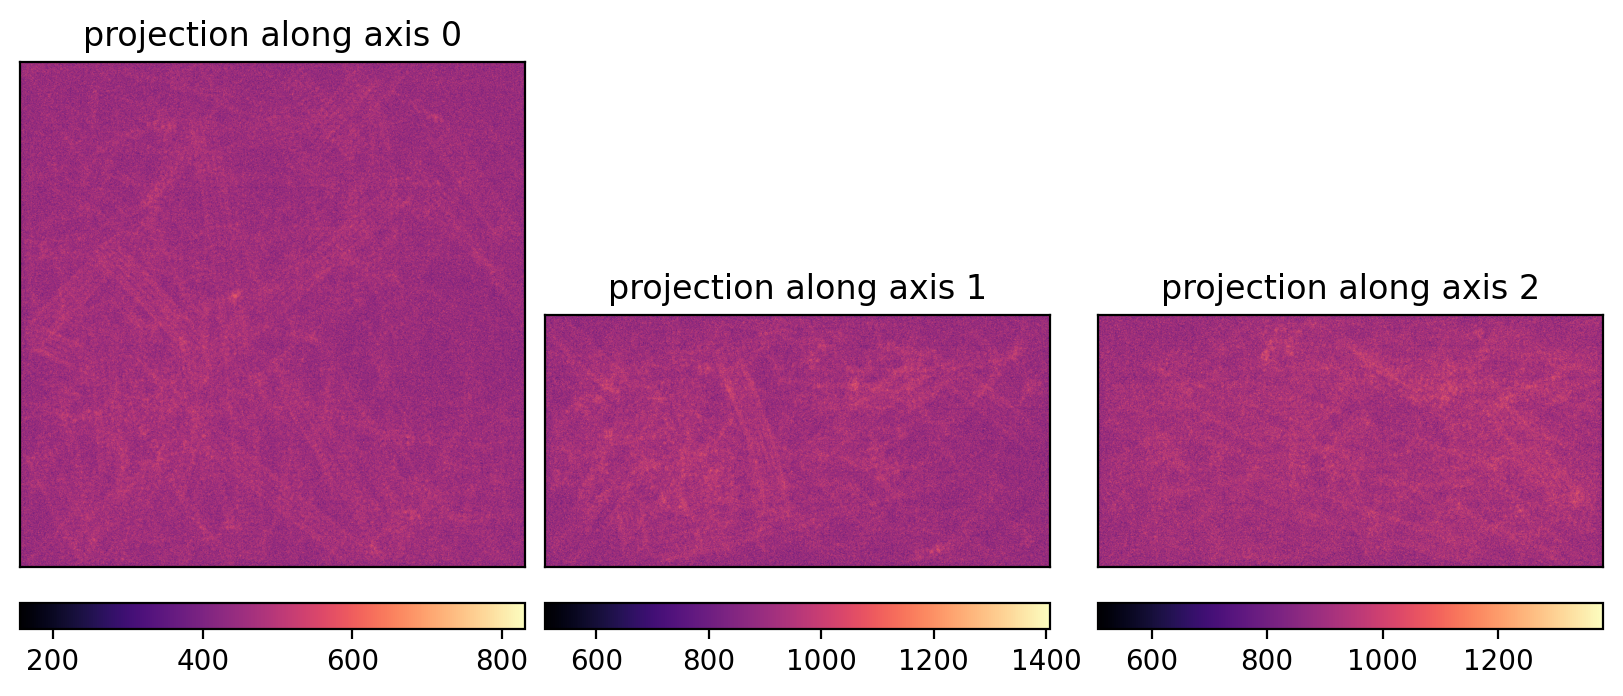

In [312]:
plot3d(tomogram, cmap="magma")

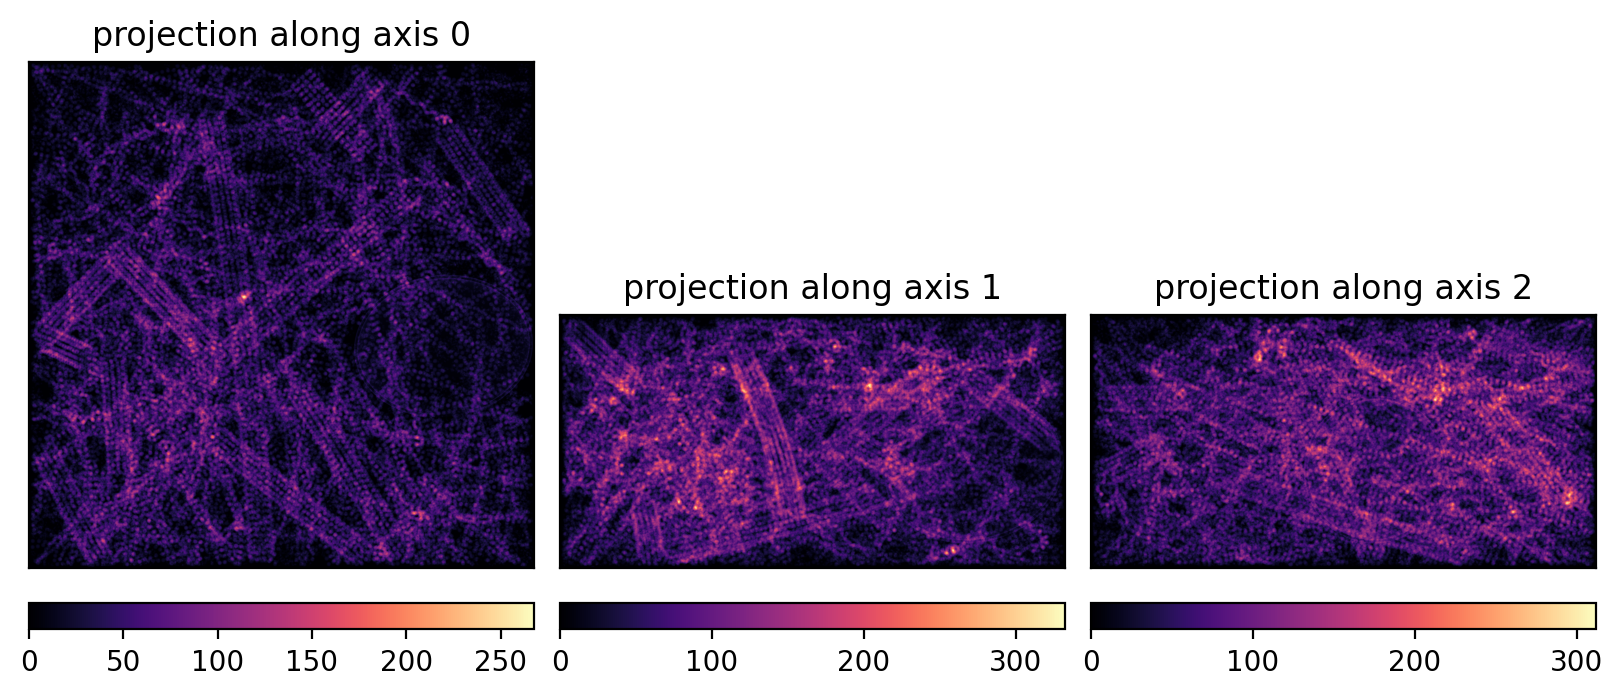

In [311]:
plot3d(tomo, cmap="magma")

## Tilt series

In [207]:
n_micrographs = 1
energy = 300  # keV
dose_per_angstrom = 2  # e-/A^2
Cs = 2e7  # angstrom. Sherical aberration, typical values are 1-3 mm.
alpha = 0.1
micrograph_size = 2048
dx = 2.0

In [208]:
device = "cuda"

In [209]:
# random defocus
defocus_min = 5000  # angstrom
defocus_max = 15000  # angstrom
defocus_A = torch.rand(n_micrographs) * (defocus_max - defocus_min) + defocus_min


# Can include 'cs', 'dfu', 'dfv', 'dfang', 'tiltx', 'tilty', 'phaseshift', 'trefoil1, 'trefoil2'
ctf_params = {
    "cs": torch.tensor([Cs] * n_micrographs).to(device),
    "dfu": defocus_A.to(device),
}

In [210]:
angles = torch.linspace(-45, 45, 19)
angles

tensor([-45., -40., -35., -30., -25., -20., -15., -10.,  -5.,   0.,   5.,  10.,
         15.,  20.,  25.,  30.,  35.,  40.,  45.])

In [211]:
scattering = Scattering(
    micrograph_size,
    dx,
    energy,
    1.0,
    scattering_model="multislice",
).to(device)
aberration = Aberration(
    micrograph_size,
    dx,
    energy,
    aberration_model="holography",
    alpha=alpha,
).to(device)
detector = Detector(
    dx,
    1.0,
    aberration_model="holography",
    noise_model="poisson",
).to(device)

In [212]:
V = tomogram * 5

In [214]:
import numpy as np

In [215]:
tilt_series = []
exit = []
clean = []
for angle in angles:
    exitwaves = scattering.multislice_and_tilt(V[None, ...], angle)

    # 3. Aberration
    # ctf_batch = {k: v[idx] for k, v in ctf_params.items()}
    detector_waves = aberration(exitwaves, ctf_params)

    # 4. Detection
    image = detector(np.sqrt(dose_per_angstrom) * detector_waves, nxy=None)

    tilt_series.append(image.detach().cpu())
    exit.append(exitwaves.detach().cpu())
    clean.append(torch.abs(detector_waves.detach().cpu() ** 2))

tilt_series = (
    torch.squeeze(torch.stack(tilt_series, dim=1)).detach().cpu()
)  # (B, N_angles, Y, X)

Output()

Output()

Output()

Output()

Output()

...

Output()

Output()

Output()

Output()

Output()

In [216]:
exit = torch.squeeze(torch.stack(exit, dim=1)).detach().cpu()  # (B, N_angles, Y, X)
clean = torch.squeeze(torch.stack(clean, dim=1)).detach().cpu()  # (B, N_angles, Y, X)

In [217]:
clean.shape

torch.Size([19, 2048, 2048])

## Animation

In [317]:
import imageio.v2 as imageio

frames = []

for idx in tqdm(range(19)):
    fig, axes = plt.subplots(1, 5, dpi=400, constrained_layout=True, figsize=(12, 4))
    [ax.set(xticks=[], yticks=[]) for ax in axes.ravel()]

    ax = axes[0]
    im = ax.imshow(
        np.unwrap(torch.angle(exit[idx]).detach().cpu()), vmin=1.3, vmax=4, cmap="magma"
    )
    ax.set(title="Exitwave Phase")
    fig.colorbar(im, ax=ax, location="bottom")

    ax = axes[1]
    im = ax.imshow(clean[idx].detach().cpu(), cmap="grey", vmax=5, vmin=1)
    ax.set(title="Intensity without Poisson")
    fig.colorbar(im, ax=ax, location="bottom")

    ax = axes[2]
    im = ax.imshow(
        butter(clean[idx].detach().cpu()), cmap="grey", vmax=4.005, vmin=3.995
    )
    ax.set(title=f"Tilt angle: {angles[idx]}\nIntensity without Poisson\nlow-passed")
    fig.colorbar(im, ax=ax, location="bottom")

    ax = axes[3]
    im = ax.imshow(tilt_series[idx].detach().cpu(), cmap="grey", vmax=10, vmin=0)
    ax.set(title="Intensity with Poisson")
    fig.colorbar(im, ax=ax, location="bottom")

    ax = axes[4]
    im = ax.imshow(
        butter(tilt_series[idx].detach().cpu()), cmap="grey", vmax=8.05, vmin=7.95
    )
    ax.set(title="Intensity with Poisson")
    fig.colorbar(im, ax=ax, location="bottom")

    fig.canvas.draw()
    # Get RGBA buffer → convert to RGB
    buf = np.asarray(fig.canvas.renderer.buffer_rgba())
    frame = buf[:, :, :3]  # drop alpha channel

    frames.append(frame)
    plt.close(fig)

# Save GIF at 2 FPS
imageio.mimsave("test.gif", frames, fps=2, loop=0, palettesize=256, subrectangles=False)
# imageio.mimsave(
#     "test.mp4",
#     frames,
#     fps=2,
#     codec="libx264",
#     quality=8,
#     format="FFMPEG"
# )

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 19/19 [00:24<00:00,  1.32s/it]


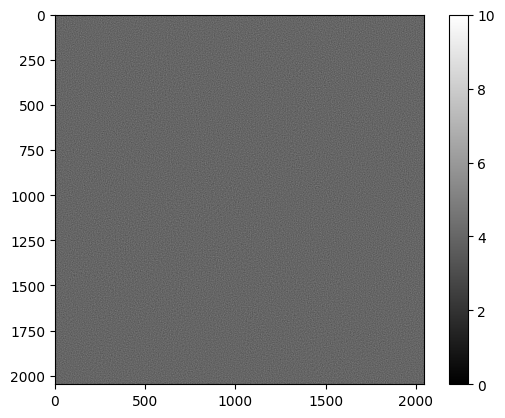

In [302]:
plt.imshow(clean[10], cmap="grey", vmax=10, vmin=0)
plt.colorbar()

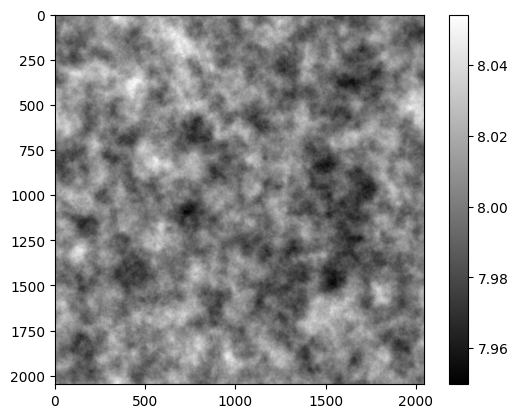

In [315]:
plt.imshow(butter(tilt_series[0]), cmap="grey")
plt.colorbar()

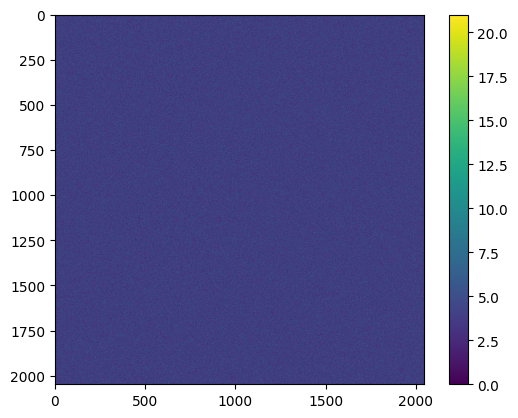

In [205]:
plt.imshow(torch.poisson(torch.abs(detector_waves.detach().cpu()[0]) ** 2))
plt.colorbar()

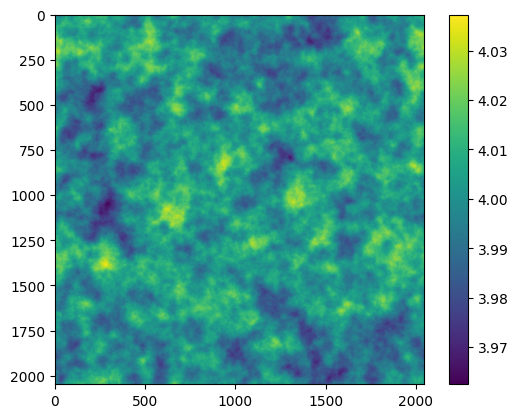

In [206]:
plt.imshow(butter(torch.poisson(torch.abs(detector_waves.detach().cpu()[0]) ** 2)))
plt.colorbar()